<a href="https://colab.research.google.com/github/dhaya0/stats_4/blob/main/CSSL_06_polynomial_regression_bias_variance_tradeoff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Polynomial regression
Let's try loading a dataset a dataset from Kaggle. To do this, you will need to [create a legacy API key from Kaggle](https://www.kaggle.com/settings). This will download a kaggle.json file.

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"dhayashrir","key":"d94fc16f7673ba32ae140507948d387f"}'}

In [2]:
# Change the permissions of the kaggle.json file such that only you can read/write the file.
# This is to prevent someone else from modifying the file.
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!pip install -q kaggle # Install that Kaggle package to interact with Kaggle's datasets; pip is python's package manager

In [4]:
!kaggle datasets download -d mirajdeepbhandari/polynomial-regression

Dataset URL: https://www.kaggle.com/datasets/mirajdeepbhandari/polynomial-regression
License(s): CC0-1.0
  0% 0.00/1.18k [00:00<?, ?B/s]
100% 1.18k/1.18k [00:00<00:00, 4.58MB/s]


In [5]:
!unzip polynomial-regression.zip

Archive:  polynomial-regression.zip
  inflating: Ice_cream selling data.csv  


In [6]:
# Import necessary packages
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score
from sklearn.preprocessing import scale, PolynomialFeatures
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.metrics import PredictionErrorDisplay

In [7]:
os.listdir() # Look for the files/directories within the current directory

['.config',
 'Ice_cream selling data.csv',
 'kaggle.json',
 'polynomial-regression.zip',
 'sample_data']

The Ice_cream selling data.csv is available!

In [8]:
data = pd.read_csv("Ice_cream selling data.csv") # Read the csv file into a pandas dataframe
type(data)

pandas.core.frame.DataFrame

In [9]:
data.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [10]:
data.shape

(49, 2)

In [11]:
data.info() # Gives basic information about the dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes


In [12]:
data.describe() # Gives basic statistics about the columns of the dataframe

,Temperature (°C),Ice Cream Sales (units)
count,49.000000,49.000000
mean,0.271755,15.905308
std,2.697672,12.264682
min,-4.662263,0.328626
25%,-2.111870,4.857988
50%,0.688781,12.615181
75%,2.784836,25.142082
max,4.899032,41.842986


In [14]:
X = data.iloc[:, :-1] # Colon implies take all rows and all columns until the last column  or [: , 0]
y = data.iloc[:, -1] # Last column is y value

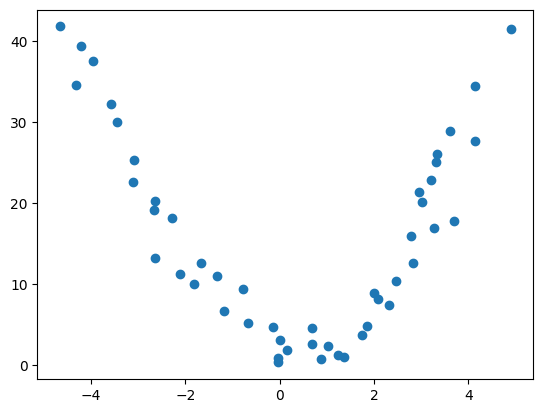

In [24]:
plt.figure()
plt.scatter (X,y)

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(34, 1) (34,) (15, 1) (15,)


In [31]:
model = LinearRegression()
model.fit(X_train,y_train)
r2_train = model.score(X_train, y_train)
r2_test = model.score(X_test, y_test)
print(f"r2 train = {r2_train} and r2 test = {r2_test}")
print(model.coef_, model.intercept_)

r2 train = 0.026645247696274632 and r2 test = 0.013527080157335392
[-0.74219439] 16.708758190473553


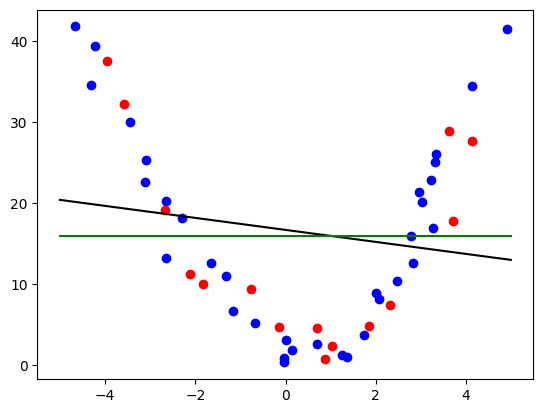

In [37]:
plt.figure()
plt.scatter(X_train, y_train, c='b')
plt.scatter(X_test, y_test, c='r')
x_values = np.arange(-5,5,0.01)
y_values = model.coef_[0]*x_values + model.intercept_
plt.plot(x_values, y_values, "k")
plt.plot(x_values, [np.mean(y)]*len(x_values),"g")

In [40]:
poly_features = PolynomialFeatures(degree=2)
X_transformed = poly_features.fit_transform(X)
X_transformed # beta 2 squared value -> last column # before columns? beta 1

array([[ 1.00000000e+00, -4.66226268e+00,  2.17366933e+01],
       [ 1.00000000e+00, -4.31655945e+00,  1.86326855e+01],
       [ 1.00000000e+00, -4.21398476e+00,  1.77576676e+01],
       [ 1.00000000e+00, -3.94966109e+00,  1.55998227e+01],
       [ 1.00000000e+00, -3.57855372e+00,  1.28060467e+01],
       [ 1.00000000e+00, -3.45571170e+00,  1.19419433e+01],
       [ 1.00000000e+00, -3.10844012e+00,  9.66239999e+00],
       [ 1.00000000e+00, -3.08130332e+00,  9.49443018e+00],
       [ 1.00000000e+00, -2.67246083e+00,  7.14204687e+00],
       [ 1.00000000e+00, -2.65228679e+00,  7.03462523e+00],
       [ 1.00000000e+00, -2.65149803e+00,  7.03044182e+00],
       [ 1.00000000e+00, -2.28826400e+00,  5.23615213e+00],
       [ 1.00000000e+00, -2.11186969e+00,  4.45999359e+00],
       [ 1.00000000e+00, -1.81893761e+00,  3.30853403e+00],
       [ 1.00000000e+00, -1.66034773e+00,  2.75675458e+00],
       [ 1.00000000e+00, -1.32637898e+00,  1.75928121e+00],
       [ 1.00000000e+00, -1.17312327e+00

In [41]:
print(X_transformed[0], X_transformed[0,1]**2)

[ 1.         -4.66226268 21.73669327] 21.73669327140054


In [42]:
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size = 0.3, random_state = 42)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(34, 3) (34,) (15, 3) (15,)


In [43]:
model = LinearRegression()
model.fit(X_train,y_train)

r2_train = model.score(X_train, y_train)
r2_test = model.score(X_test, y_test)
print(f"r2 train = {r2_train} and r2 test = {r2_test}")
print(model.coef_, model.intercept_)

r2 train = 0.9401457258288188 and r2 test = 0.8994543494249359
[ 0.         -0.58415772  1.83742584] 2.931702446180669


In [48]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

train_error = mean_squared_error(y_train, y_pred_train)
test_error = mean_squared_error(y_test, y_pred_test)
print(f"train error = {train_error} and test error = {test_error}")

train error = 9.135759105464622 and test error = 13.36027498142077


Plot the degrees of polynomial vs MSE

# Task
Perform polynomial regression on the "Ice_cream selling data.csv" dataset. For each polynomial degree from 1 to 10, create polynomial features from the `Temperature (°C)` column (X), split the data into training and testing sets, train a `LinearRegression` model, and calculate the Mean Squared Error (MSE) for both training and testing sets. Finally, generate a plot showing the training MSE and testing MSE against the polynomial degrees, including a legend and appropriate axis labels.

## Initialize lists for MSEs

### Subtask:
Initialize empty lists to store the training and testing Mean Squared Error (MSE) values for each polynomial degree.


**Reasoning**:
I need to initialize two empty lists, `train_mse_errors` and `test_mse_errors`, as per the instructions.



In [64]:
train_mse_errors = []
test_mse_errors = []
print("Initialized empty lists for MSEs.")

Initialized empty lists for MSEs.


**Reasoning**:
The subtask is to iterate through polynomial degrees from 1 to 10, create polynomial features, train a linear regression model, and calculate the training and testing MSEs for each degree. This step initiates that loop.



In [65]:
for degree in range(1, 11):
    poly_features = PolynomialFeatures(degree=degree)
    X_poly = poly_features.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.3, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    train_mse = mean_squared_error(y_train, y_pred_train)
    test_mse = mean_squared_error(y_test, y_pred_test)

    train_mse_errors.append(train_mse)
    test_mse_errors.append(test_mse)

print("Polynomial regression for degrees 1 to 10 completed and MSEs stored.")

Polynomial regression for degrees 1 to 10 completed and MSEs stored.


**Reasoning**:
The next step in the main task is to generate a plot showing the training MSE and testing MSE against the polynomial degrees. I need to create a code block that uses matplotlib to visualize these errors.



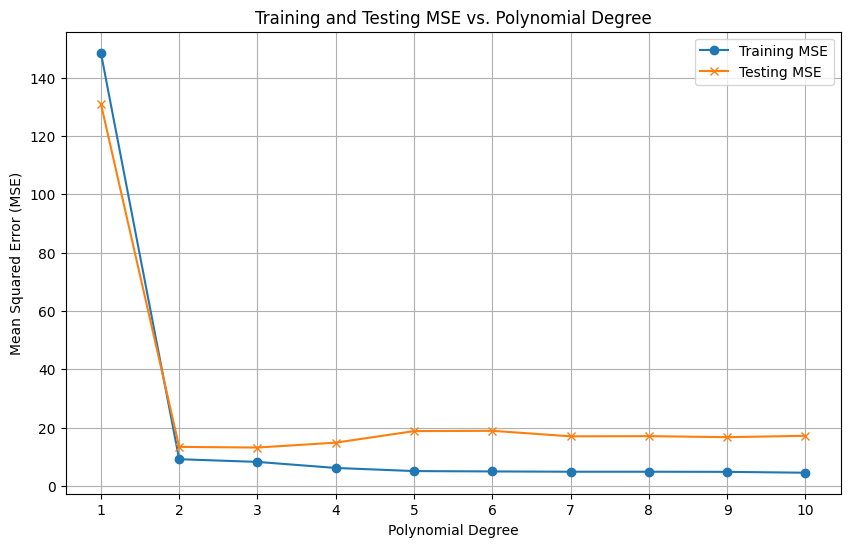

Plot showing training and testing MSEs generated.


In [66]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), train_mse_errors, label='Training MSE', marker='o')
plt.plot(range(1, 11), test_mse_errors, label='Testing MSE', marker='x')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Training and Testing MSE vs. Polynomial Degree')
plt.xticks(range(1, 11))
plt.grid(True)
plt.legend()
plt.show()
print("Plot showing training and testing MSEs generated.")

## Final Task

### Subtask:
Review the generated plot to understand how model complexity (polynomial degree) affects training and test error, and discuss potential overfitting or underfitting.


## Summary:

### Q&A
*   **How does model complexity (polynomial degree) affect training and test error?**
    As the polynomial degree (model complexity) increases, the training Mean Squared Error (MSE) generally decreases, indicating that the model fits the training data more closely. The test MSE, however, typically follows a U-shaped curve: it initially decreases as the model captures more underlying patterns, reaches a minimum at an optimal complexity, and then increases significantly as the model becomes too complex.
*   **Discuss potential overfitting or underfitting.**
    *   **Underfitting** is observed at lower polynomial degrees (e.g., degrees 1-2), where both training and testing MSEs are relatively high. This indicates that the model is too simple to capture the essential patterns in the data.
    *   **Overfitting** becomes evident at higher polynomial degrees (e.g., degrees 6-10), where the training MSE continues to be very low (or approaches zero), but the testing MSE starts to rise considerably. This indicates that the model has learned noise or specific characteristics of the training data that do not generalize well to unseen data.

### Data Analysis Key Findings
*   **Underfitting at Low Complexity:** For lower polynomial degrees (e.g., 1 or 2), both the training and testing Mean Squared Errors (MSEs) are relatively high, suggesting that the model is too simplistic to effectively capture the relationship between temperature and ice cream sales.
*   **Consistent Decrease in Training Error:** As the polynomial degree increases, the training MSE consistently decreases, indicating that the model is progressively fitting the training data more closely with added complexity.
*   **Optimal Complexity and Subsequent Increase in Test Error:** The testing MSE initially decreases with increasing polynomial degree, reaching a minimum point. Beyond this optimal point, further increases in polynomial degree lead to a rise in testing MSE, while the training MSE continues its downward trend or levels off at a very low value.
*   **Clear Evidence of Overfitting:** At higher polynomial degrees (e.g., from degree 6 to 10), there is a significant divergence between the training and testing MSE. The training MSE is very low, but the testing MSE is substantially higher, which clearly demonstrates that the model is overfitting the training data.

### Insights or Next Steps
*   The optimal polynomial degree for modeling this dataset is likely found at the point where the testing MSE is minimized, which would typically be an intermediate degree (e.g., around degree 3-5). This degree offers the best balance between model bias and variance.
*   To build a robust predictive model, it is crucial to select a polynomial degree that minimizes the generalization error (testing MSE) rather than solely focusing on minimizing the training error. Techniques like cross-validation could be employed to more precisely identify this optimal degree and improve model reliability.


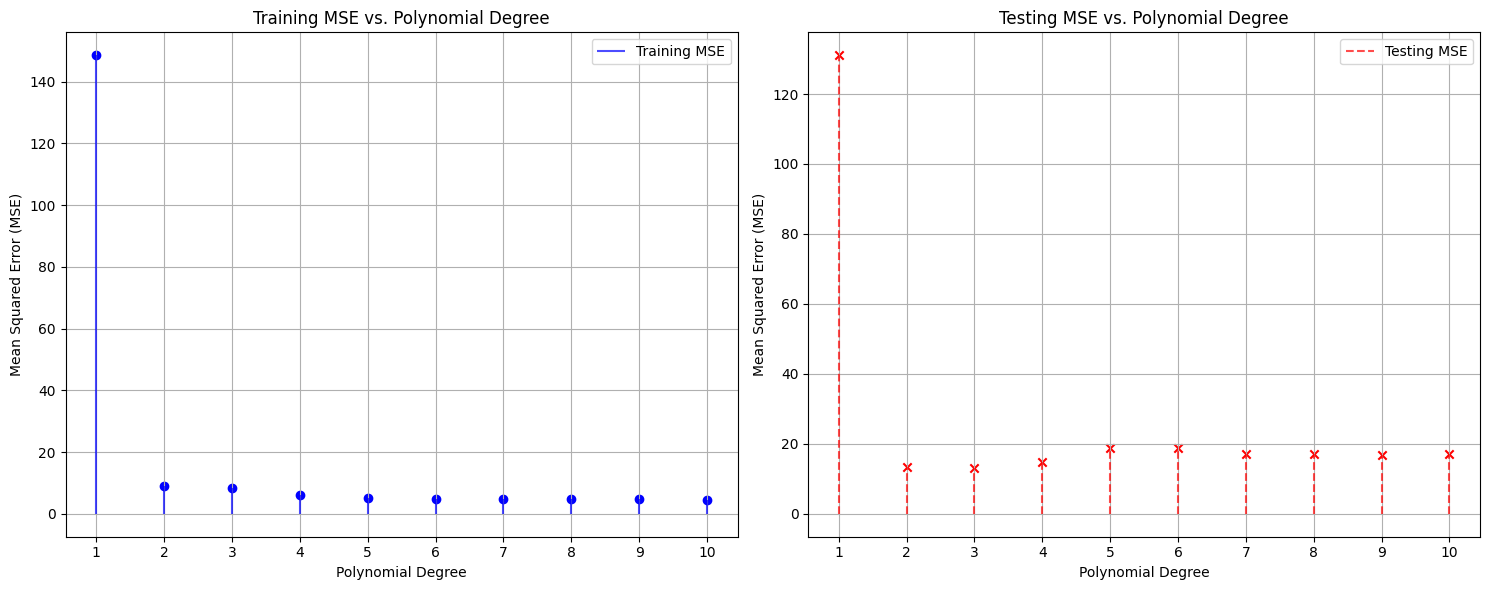

Separate plots showing training and testing MSEs generated using vlines.


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot Training MSE
axes[0].vlines(range(1, 11), [0]*len(train_mse_errors), train_mse_errors, colors='b', linestyles='solid', label='Training MSE', alpha=0.7)
axes[0].scatter(range(1, 11), train_mse_errors, color='b', marker='o')
axes[0].set_xlabel('Polynomial Degree')
axes[0].set_ylabel('Mean Squared Error (MSE)')
axes[0].set_title('Training MSE vs. Polynomial Degree')
axes[0].set_xticks(range(1, 11))
axes[0].grid(True)
axes[0].legend()

# Plot Testing MSE
axes[1].vlines(range(1, 11), [0]*len(test_mse_errors), test_mse_errors, colors='r', linestyles='dashed', label='Testing MSE', alpha=0.7)
axes[1].scatter(range(1, 11), test_mse_errors, color='r', marker='x')
axes[1].set_xlabel('Polynomial Degree')
axes[1].set_ylabel('Mean Squared Error (MSE)')
axes[1].set_title('Testing MSE vs. Polynomial Degree')
axes[1].set_xticks(range(1, 11))
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()
print("Separate plots showing training and testing MSEs generated using vlines.")